--- Airline Frequencies ---
airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64


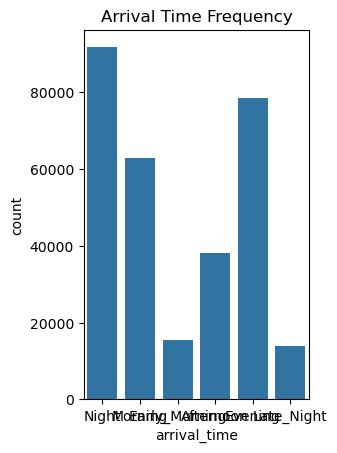

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD DATA
df = pd.read_csv('flights_data.csv')

# Q.1 What are the airlines in the dataset, accompanied by their frequencies?
airline_counts = df['airline'].value_counts()
print("--- Airline Frequencies ---")
print(airline_counts)

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='arrival_time')
plt.title('Arrival Time Frequency')
plt.show()


Text(0.5, 1.0, 'Departure Time Frequency')

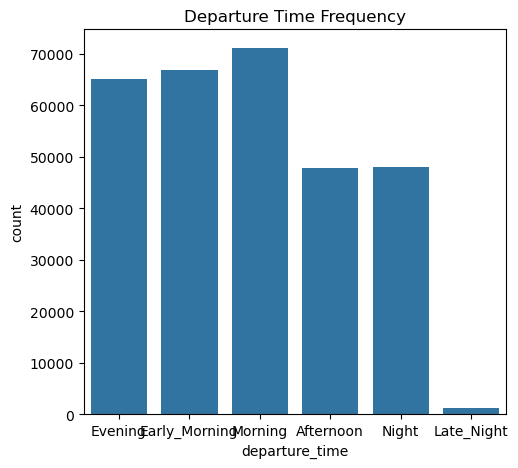

In [5]:
# Q.2. Bar Graphs for Departure Time & Arrival Time
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='departure_time')
plt.title('Departure Time Frequency')


Text(0.5, 1.0, 'Source City Frequency')

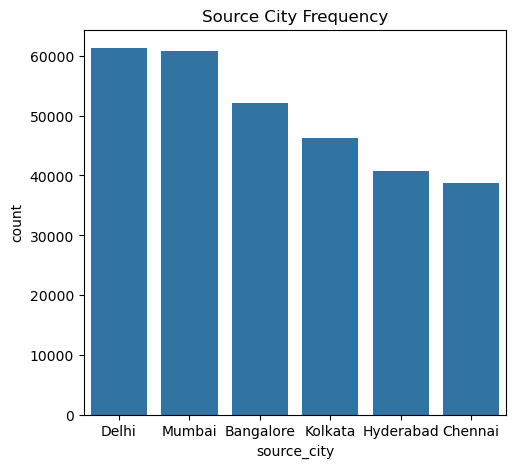

In [6]:
# Q.3. Bar Graphs for Source City & Destination City
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='source_city')
plt.title('Source City Frequency')


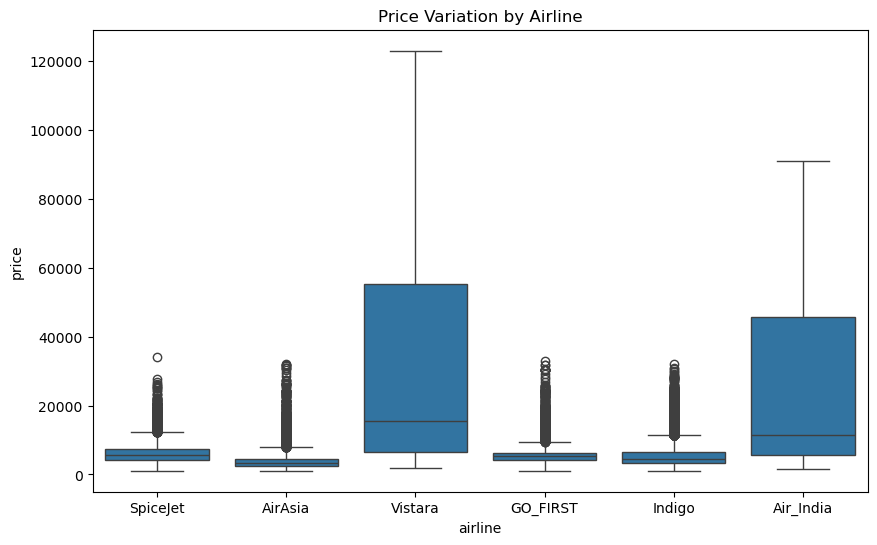

In [7]:
# Q.4. Does price vary with airlines? (Visualizing Price vs Airline)
plt.figure(figsize=(10, 6))
sns.boxplot(x='airline', y='price', data=df)
plt.title('Price Variation by Airline')
plt.show()


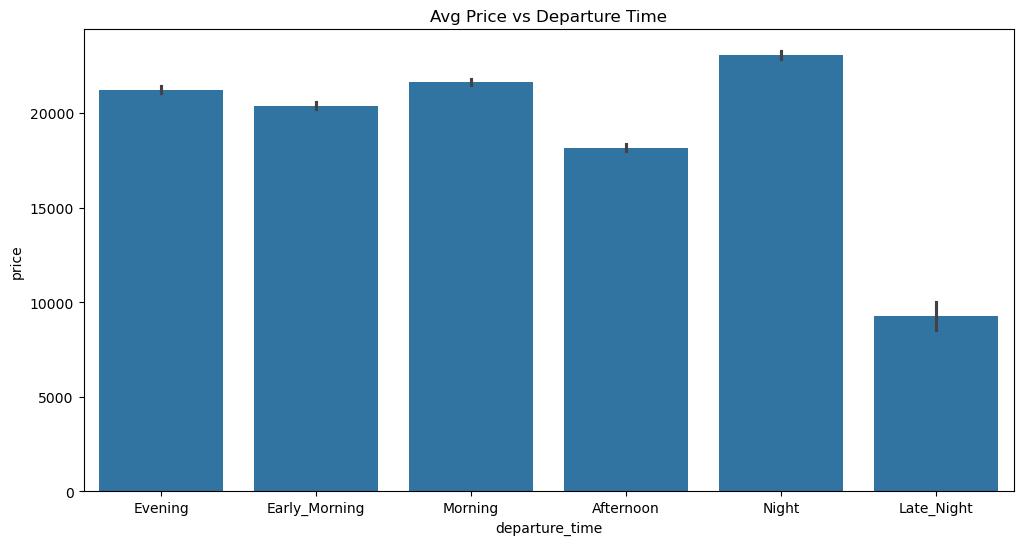

In [8]:
# Q.5. Ticket price change based on departure/arrival time?
plt.figure(figsize=(12, 6))
sns.barplot(x='departure_time', y='price', data=df)
plt.title('Avg Price vs Departure Time')
plt.show()

In [9]:
# Q.6. Price changes with Source and Destination?
# Using a pivot table to see average price between cities
city_price = df.groupby(['source_city', 'destination_city'])['price'].mean().unstack()
print("\n--- Average Price Matrix (Source vs Destination) ---")
print(city_price)


--- Average Price Matrix (Source vs Destination) ---
destination_city     Bangalore       Chennai         Delhi     Hyderabad  \
source_city                                                                
Bangalore                  NaN  23321.850078  17723.313972  21226.121192   
Chennai           25081.850454           NaN  18981.863948  21591.345404   
Delhi             17880.216315  19369.881354           NaN  17347.288379   
Hyderabad         21347.177998  21848.065989  17243.945685           NaN   
Kolkata           22744.808428  23660.361040  19422.354559  21500.011397   
Mumbai            23147.873807  22781.899112  18725.320008  21004.046705   

destination_city       Kolkata        Mumbai  
source_city                                   
Bangalore         23500.061229  23128.618672  
Chennai           22669.932407  22765.849647  
Delhi             20566.409418  19355.829812  
Hyderabad         20823.893201  20080.865759  
Kolkata                    NaN  22078.883579  
Mumbai  

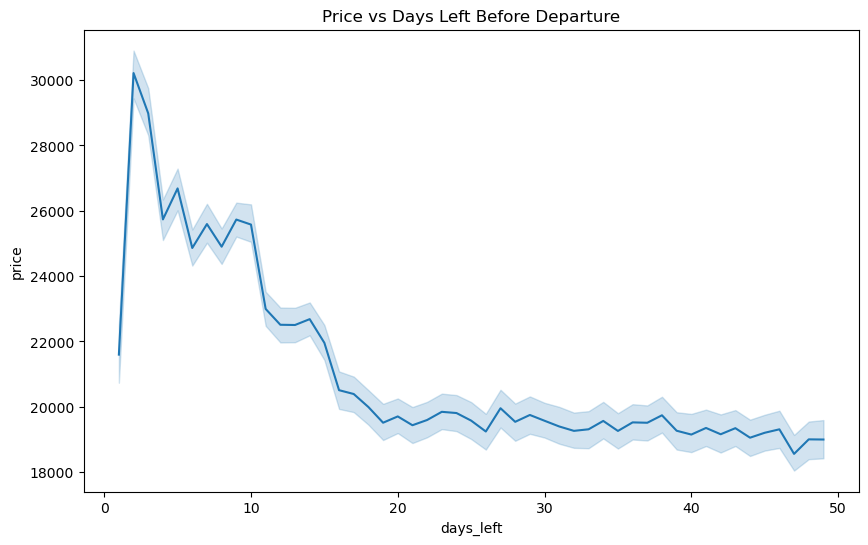

In [10]:
# Q.7. Price affected when bought 1 or 2 days before departure?
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='days_left', y='price')
plt.title('Price vs Days Left Before Departure')
plt.show()


--- Average Price by Class ---
class
Business    52540.081124
Economy      6572.342383
Name: price, dtype: float64


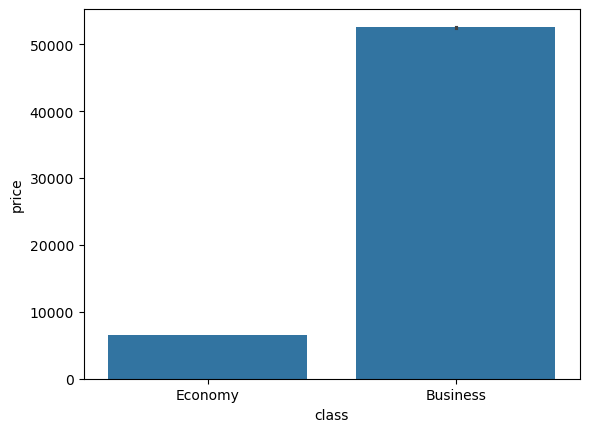

In [11]:
# Q.8. Price variation between Economy and Business class?
class_price = df.groupby('class')['price'].mean()
print("\n--- Average Price by Class ---")
print(class_price)
sns.barplot(x='class', y='price', data=df)
plt.show()

In [12]:
# Q.9. Average Price of Vistara from Delhi to Hyderabad in Business Class?
vistara_bh = df[
    (df['airline'] == 'Vistara') & 
    (df['source_city'] == 'Delhi') & 
    (df['destination_city'] == 'Hyderabad') & 
    (df['class'] == 'Business')
]
avg_price = vistara_bh['price'].mean()
print(f"\nAvg Price for Vistara (Delhi -> Hyd, Business): ₹{avg_price:.2f}")


Avg Price for Vistara (Delhi -> Hyd, Business): ₹47939.84
